## Self-Pruning Neural Network – Report

### Why L1 on Sigmoid Gates Encourages Sparsity

The sparsity loss is defined as the L1 norm of gate values:

    Sparsity Loss = sum(sigmoid(gate_scores))

Since gate values lie between 0 and 1, minimizing this term pushes many gates toward 0.

- A gate value close to 0 effectively removes the corresponding weight
- A gate value close to 1 keeps the connection active

The L1 penalty encourages many small values to shrink to zero, resulting in sparse connectivity.

Thus, the model learns to deactivate unimportant connections while preserving important ones.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 52.8MB/s]


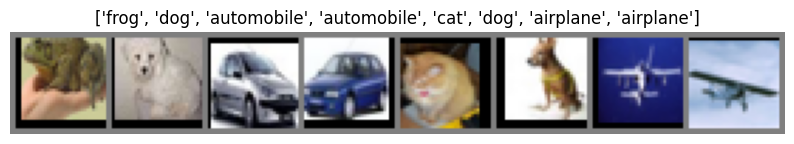

In [3]:
import matplotlib.pyplot as plt
import numpy as np

classes = trainset.classes

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# Get a batch
dataiter = iter(trainloader)
images, labels = next(dataiter)

plt.figure(figsize=(10,5))
imshow(torchvision.utils.make_grid(images[:8]))
plt.title([classes[l] for l in labels[:8]])
plt.show()

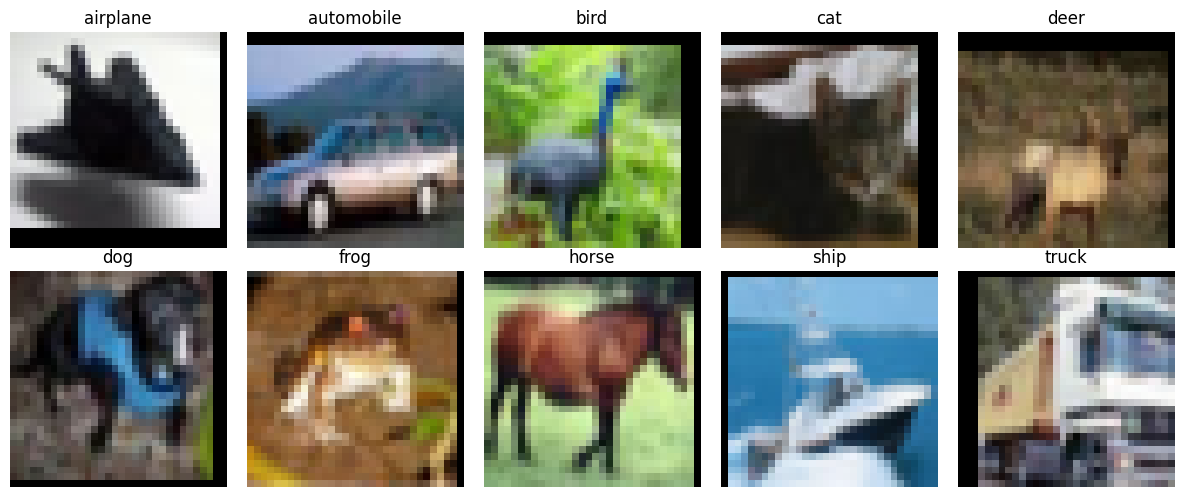

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))

shown = {i: False for i in range(10)}

for img, label in trainset:
    if not shown[label]:
        row, col = divmod(label, 5)

        img = img / 2 + 0.5
        axes[row, col].imshow(np.transpose(img.numpy(), (1,2,0)))
        axes[row, col].set_title(classes[label])
        axes[row, col].axis('off')

        shown[label] = True

    if all(shown.values()):
        break

plt.tight_layout()
plt.show()

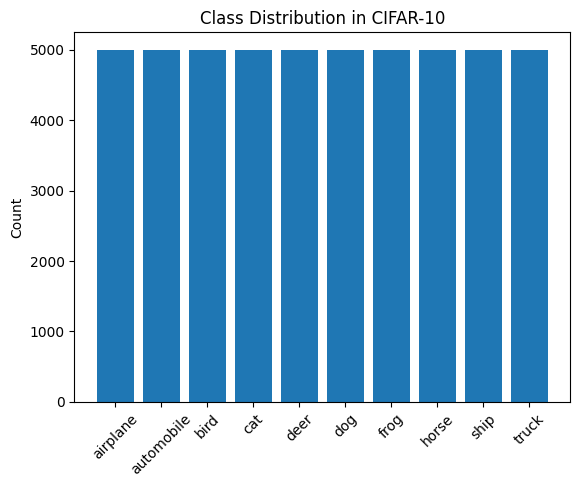

In [5]:
from collections import Counter

labels = [label for _, label in trainset]
counts = Counter(labels)

plt.bar(classes, [counts[i] for i in range(10)])
plt.xticks(rotation=45)
plt.title("Class Distribution in CIFAR-10")
plt.ylabel("Count")
plt.show()

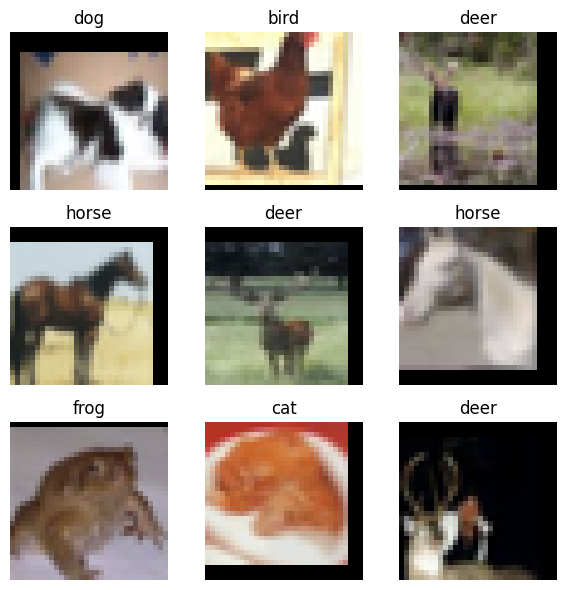

In [6]:
indices = np.random.choice(len(trainset), 9, replace=False)

plt.figure(figsize=(6,6))

for i, idx in enumerate(indices):
    img, label = trainset[idx]

    plt.subplot(3,3,i+1)
    img = img / 2 + 0.5
    plt.imshow(np.transpose(img.numpy(), (1,2,0)))
    plt.title(classes[label])
    plt.axis('off')

plt.tight_layout()
plt.show()

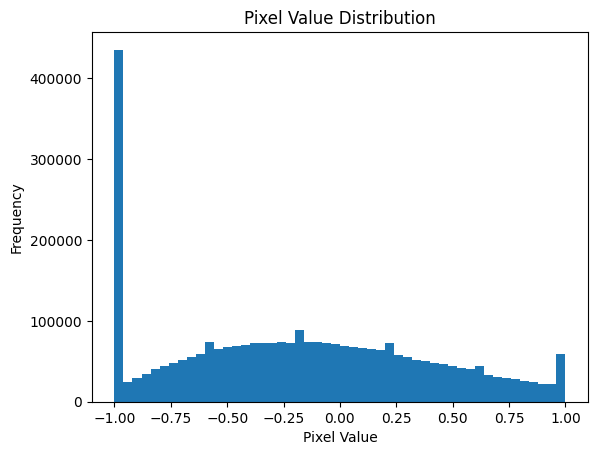

In [7]:
all_pixels = []

for i in range(1000):  # sample subset for speed
    img, _ = trainset[i]
    all_pixels.append(img.numpy().flatten())

all_pixels = np.concatenate(all_pixels)

plt.hist(all_pixels, bins=50)
plt.title("Pixel Value Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [8]:
# Custom linear layer with learnable gates for pruning
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.02)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Bias toward pruning (important)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) - 2.0)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def gate_values(self):
        return torch.sigmoid(self.gate_scores)

In [9]:
class HybridNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc1 = PrunableLinear(128*4*4, 256)
        self.fc2 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        return self.fc2(x)

    def get_all_gates(self):
        gates = []
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                gates.append(m.gate_values().view(-1))
        return torch.cat(gates)

In [10]:
# L1 penalty on gate values encourages sparsity
def sparsity_loss(model):
    total = 0
    for m in model.modules():
        if isinstance(m, PrunableLinear):
            total += torch.sum(m.gate_values())
    return total

In [11]:
def evaluate_accuracy(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in testloader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)

            total += y.size(0)
            correct += (preds == y).sum().item()

    return 100 * correct / total

def evaluate_accuracy_train(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in trainloader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)

            total += y.size(0)
            correct += (preds == y).sum().item()

    return 100 * correct / total


def compute_sparsity(model, threshold=1e-2):
    gates = model.get_all_gates().detach().cpu().numpy()
    return (gates < threshold).mean() * 100

In [12]:
def train_model(lambda_val, epochs=15):

    model = HybridNet().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss()

    train_acc_list = []
    test_acc_list = []

    best_acc = 0
    best_model = None
    best_gates = None

    for epoch in range(epochs):
        model.train()

        for x, y in trainloader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()

            outputs = model(x)

            cls_loss = criterion(outputs, y)
            sp_loss = sparsity_loss(model)

            # Total loss combines classification and sparsity penalty
            loss = cls_loss + lambda_val * sp_loss

            loss.backward()
            optimizer.step()

        #Compute accuracies AFTER each epoch
        train_acc = evaluate_accuracy_train(model)
        test_acc = evaluate_accuracy(model)

        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        acc = evaluate_accuracy(model)

        if acc > best_acc:
            best_acc = acc
            best_model = model.state_dict()
            best_gates = model.get_all_gates().detach().cpu().numpy()

        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
        
    model.load_state_dict(best_model)
    return model, train_acc_list, test_acc_list, best_gates

In [13]:
lambdas = [1e-6, 5e-6, 1e-5, 1e-4, 1e-3, 5e-3]

results = []
all_gates = []

for lam in lambdas:
    print(f"\n===== Lambda: {lam} =====")

    model, train_acc_list, test_acc_list, best_gates = train_model(lambda_val=lam)

    acc = evaluate_accuracy(model)
    sparsity = compute_sparsity(model)

    results.append((lam, acc, sparsity))
    all_gates.append(best_gates)

    print(f"Accuracy: {acc:.2f}%")
    print(f"Sparsity: {sparsity:.2f}%")


===== Lambda: 1e-06 =====
Epoch 1 | Train Acc: 40.94% | Test Acc: 43.40%
Epoch 2 | Train Acc: 48.63% | Test Acc: 50.53%
Epoch 3 | Train Acc: 51.68% | Test Acc: 54.67%
Epoch 4 | Train Acc: 56.07% | Test Acc: 59.35%
Epoch 5 | Train Acc: 59.45% | Test Acc: 62.08%
Epoch 6 | Train Acc: 61.89% | Test Acc: 64.68%
Epoch 7 | Train Acc: 65.78% | Test Acc: 68.30%
Epoch 8 | Train Acc: 66.76% | Test Acc: 68.66%
Epoch 9 | Train Acc: 69.23% | Test Acc: 71.23%
Epoch 10 | Train Acc: 69.14% | Test Acc: 71.88%
Epoch 11 | Train Acc: 71.51% | Test Acc: 72.85%
Epoch 12 | Train Acc: 72.12% | Test Acc: 73.27%
Epoch 13 | Train Acc: 74.20% | Test Acc: 74.87%
Epoch 14 | Train Acc: 72.51% | Test Acc: 72.96%
Epoch 15 | Train Acc: 74.94% | Test Acc: 76.28%
Accuracy: 76.28%
Sparsity: 35.06%

===== Lambda: 5e-06 =====
Epoch 1 | Train Acc: 39.08% | Test Acc: 42.81%
Epoch 2 | Train Acc: 47.21% | Test Acc: 50.14%
Epoch 3 | Train Acc: 51.45% | Test Acc: 53.10%
Epoch 4 | Train Acc: 55.74% | Test Acc: 59.18%
Epoch 5 | Tra

In [14]:
print("\n===== FINAL RESULTS =====")
print("{:<10} {:<15} {:<15}".format("Lambda", "Accuracy", "Sparsity"))

for lam, acc, sparsity in results:
    print("{:<10.1e} {:<15.2f} {:<15.2f}".format(lam, acc, sparsity))


===== FINAL RESULTS =====
Lambda     Accuracy        Sparsity       
1.0e-06    76.28           35.06          
5.0e-06    75.34           43.69          
1.0e-05    75.24           50.67          
1.0e-04    73.11           62.59          
1.0e-03    69.17           77.16          
5.0e-03    67.17           81.31          


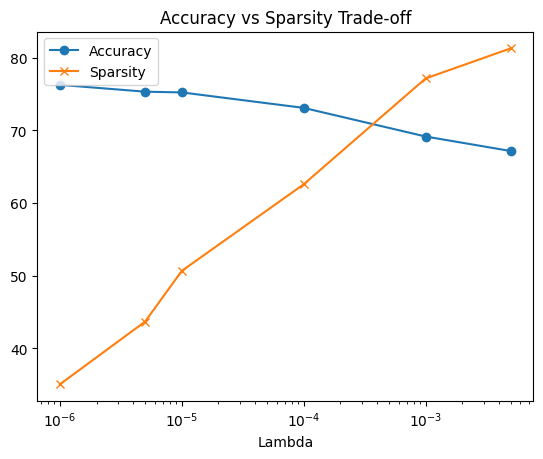

In [15]:
lams = [r[0] for r in results]
accs = [r[1] for r in results]
spars = [r[2] for r in results]

plt.plot(lams, accs, marker='o', label='Accuracy')
plt.plot(lams, spars, marker='x', label='Sparsity')

plt.xscale('log')
plt.xlabel("Lambda")
plt.title("Accuracy vs Sparsity Trade-off")
plt.legend()
plt.show()

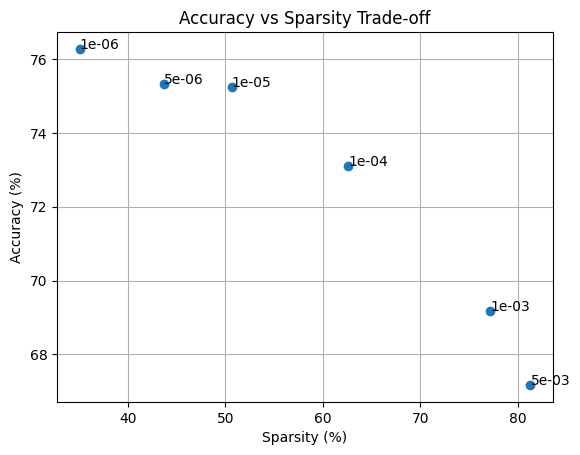

In [16]:
accs = [r[1] for r in results]
spars = [r[2] for r in results]

plt.figure()
plt.scatter(spars, accs)
for i, lam in enumerate([r[0] for r in results]):
    plt.text(spars[i], accs[i], f"{lam:.0e}")

plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Sparsity Trade-off")
plt.grid()
plt.show()


Best Model Lambda: 1e-06


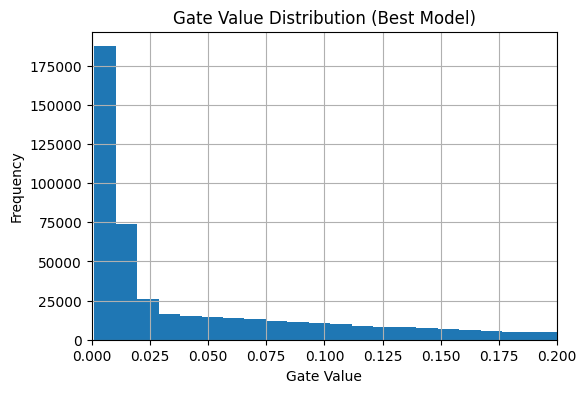

In [17]:
best_lambda_idx = np.argmax([r[1] for r in results])

best_model_lambda = results[best_lambda_idx][0]
gates = all_gates[best_lambda_idx]

print(f"\nBest Model Lambda: {best_model_lambda}")

plt.figure(figsize=(6,4))
plt.hist(gates, bins=100)
plt.xlim(0, 0.2)
plt.title("Gate Value Distribution (Best Model)")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Gate Distribution Analysis

The histogram shows the distribution of learned gate values.

Observations:
- A large spike near 0 indicates many gates are effectively turned off (pruned connections)
- A smaller cluster away from 0 represents important active connections

This confirms that the model successfully learns sparse representations rather than randomly suppressing weights.

In [18]:
print("Total Gates:", len(gates))
print("Pruned (<0.01):", (gates < 1e-2).sum())
print("Active:", (gates >= 1e-2).sum())

Total Gates: 526848
Pruned (<0.01): 184704
Active: 342144


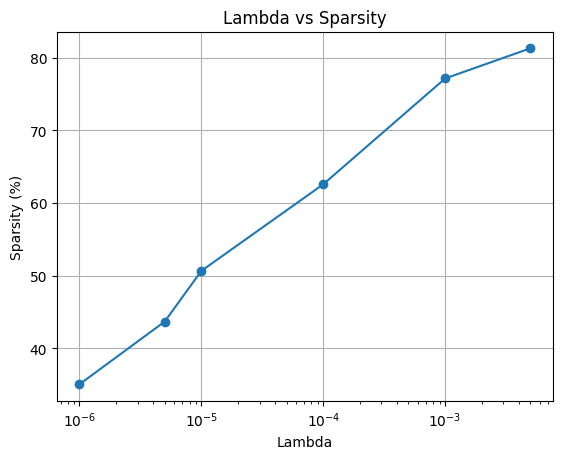

In [19]:
lams = [r[0] for r in results]
spars = [r[2] for r in results]

plt.figure()
plt.plot(lams, spars, marker='o')
plt.xscale('log')
plt.xlabel("Lambda")
plt.ylabel("Sparsity (%)")
plt.title("Lambda vs Sparsity")
plt.grid()
plt.show()

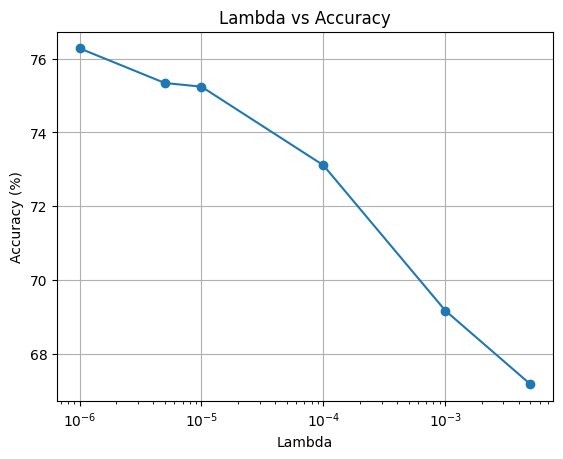

In [20]:
accs = [r[1] for r in results]

plt.figure()
plt.plot(lams, accs, marker='o')
plt.xscale('log')
plt.xlabel("Lambda")
plt.ylabel("Accuracy (%)")
plt.title("Lambda vs Accuracy")
plt.grid()
plt.show()

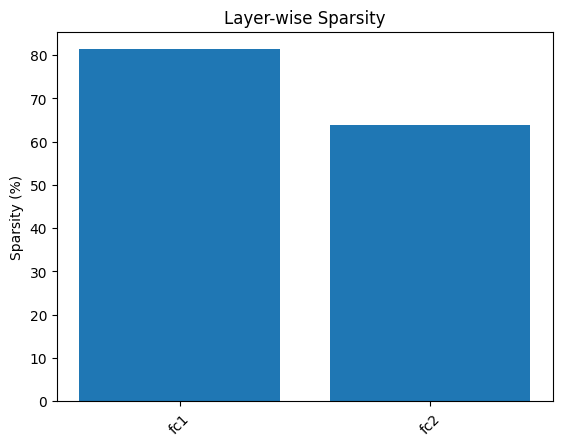

In [21]:
def layer_wise_sparsity(model):
    layer_sparsity = {}

    for name, m in model.named_modules():
        if isinstance(m, PrunableLinear):
            gates = m.gate_values().detach().cpu().numpy()
            # Percentage of gates effectively turned off (pruned)
            sparsity = (gates < 1e-2).mean() * 100
            layer_sparsity[name] = sparsity

    return layer_sparsity


layer_stats = layer_wise_sparsity(model)

plt.bar(layer_stats.keys(), layer_stats.values())
plt.xticks(rotation=45)
plt.ylabel("Sparsity (%)")
plt.title("Layer-wise Sparsity")
plt.show()

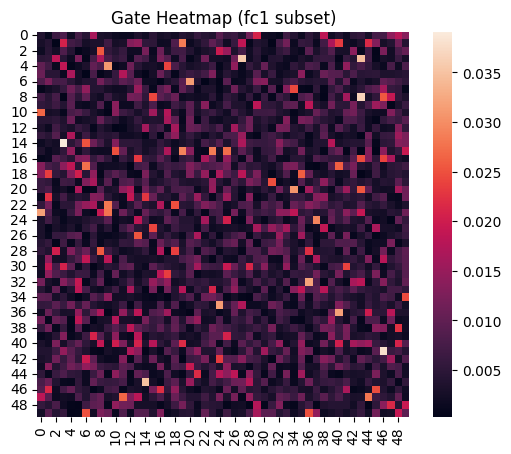

In [22]:
import seaborn as sns

gates = model.fc1.gate_values().detach().cpu().numpy()

plt.figure(figsize=(6,5))
sns.heatmap(gates[:50, :50])  # subset
plt.title("Gate Heatmap (fc1 subset)")
plt.show()

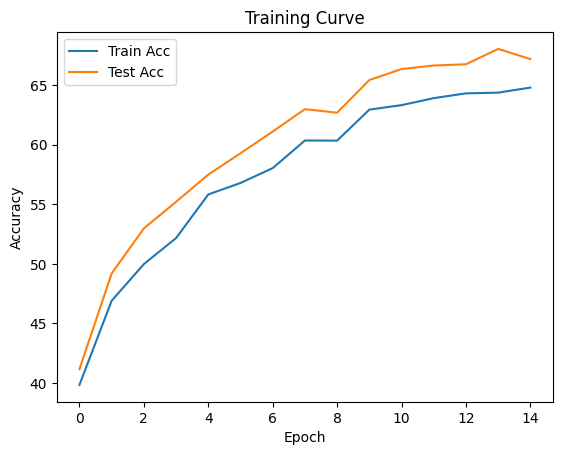

In [23]:
plt.plot(train_acc_list, label="Train Acc")
plt.plot(test_acc_list, label="Test Acc")
plt.legend()
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

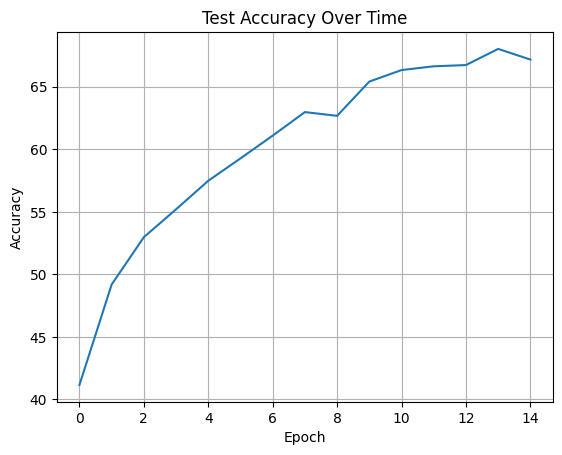

In [24]:
plt.plot(test_acc_list)
plt.title("Test Accuracy Over Time")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.show()